In [ ]:
## News headline classifier

## Install dependencies

In [16]:
# install required libraries (run once if needed)
%pip install -q pandas scikit-learn joblib seaborn matplotlib


Note: you may need to restart the kernel to use updated packages.


## Imports & configuration

In [3]:
#  imports and basic config
import os
import re
import joblib
import logging
from typing import List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, FileLink, HTML

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

# Visual settings
%matplotlib inline
sns.set_style("whitegrid")

# Logging & reproducibility
logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
logger = logging.getLogger(__name__)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)



## Create dataset (100 records)

In [9]:
# Step 1: Import pandas
import pandas as pd

# Step 2: Create sample dataset with 100 records
headlines = [
    # Politics (25)
    "Government passes new education bill",
    "President addresses the nation on economic reforms",
    "Parliament debates new tax policy",
    "Election commission announces voter guidelines",
    "Opposition criticizes foreign policy decisions",
    "Senate approves defense budget",
    "Prime Minister meets foreign dignitaries",
    "Local elections results spark debate",
    "New bill aims to improve healthcare system",
    "Political parties gear up for upcoming elections",
    "Government launches anti-corruption drive",
    "Minister resigns over scandal",
    "New trade agreement signed with neighboring country",
    "Protests erupt over proposed legislation",
    "Governor addresses environmental concerns",
    "Policy reforms to boost employment announced",
    "Lawmakers discuss cybersecurity measures",
    "Budget session highlights key economic reforms",
    "Parliamentary committee investigates financial fraud",
    "New immigration policy announced",
    "Opposition leaders meet to form coalition",
    "Government plans infrastructure development",
    "Political tensions rise over international relations",
    "Cabinet reshuffle announced",
    "Election campaigns begin across the country",
    
    # Business (25)
    "Stock markets hit record high this week",
    "Company X acquires startup Y for $2 billion",
    "Tech firms announce quarterly earnings",
    "Global oil prices rise amid tensions",
    "Bank announces new interest rate policy",
    "Retail sales show unexpected growth",
    "Investment in renewable energy surges",
    "Company Y faces lawsuit over patent infringement",
    "Entrepreneur launches new fintech platform",
    "Industry leaders discuss digital transformation",
    "Trade deficit narrows as exports increase",
    "Real estate sector sees uptick in sales",
    "Merger between Company A and Company B approved",
    "New government regulations impact small businesses",
    "Startups receive record funding this year",
    "Automobile sales drop due to economic slowdown",
    "Tech giant unveils innovative product",
    "Business leaders meet for annual summit",
    "Foreign investments flow into domestic market",
    "Banking sector undergoes major reforms",
    "Stock trading volumes soar",
    "E-commerce platforms expand globally",
    "Corporate tax changes announced",
    "Entrepreneurship rises among young professionals",
    "Global trade talks continue this week",
    
    # Sports (25)
    "Team A wins the championship final",
    "Star player breaks national record",
    "Olympic committee announces new rules",
    "Coach resigns after poor performance",
    "Local team qualifies for international tournament",
    "Football league finals scheduled for Sunday",
    "Tennis player wins grand slam title",
    "New stadium inaugurated for sports events",
    "Cricket team announces squad for upcoming series",
    "Marathon sees record participation this year",
    "Basketball league announces playoff schedule",
    "Athlete sets new world record in sprint",
    "National team prepares for friendly match",
    "Sports federation introduces new training programs",
    "Top golfer wins international tournament",
    "Swimming championship concludes successfully",
    "Rugby team advances to semifinals",
    "Sports awards ceremony held last night",
    "Local athletes excel in regional games",
    "Cycling competition attracts international riders",
    "Volleyball team secures championship title",
    "Youth sports programs expanded nationwide",
    "National sports policy revised",
    "Athletes advocate for better facilities",
    "Sports sponsorship deals signed",
    
    # Entertainment (25)
    "New movie breaks box office records",
    "Famous singer releases latest album",
    "Award ceremony celebrates top actors",
    "Film festival showcases indie films",
    "Celebrity couple announces engagement",
    "TV series finale draws huge audience",
    "Music awards announced last night",
    "New streaming platform launches",
    "Director announces upcoming blockbuster",
    "Actor wins international award",
    "Concert tour tickets sell out quickly",
    "Film receives critical acclaim",
    "Celebrity opens charity foundation",
    "Movie trailer trends online",
    "Pop star collaborates with famous producer",
    "Documentary highlights social issues",
    "Broadway show receives rave reviews",
    "Actress stars in new thriller",
    "Music festival attracts thousands",
    "Reality show gains popularity",
    "Comedy special streams worldwide",
    "Singer performs at charity event",
    "Film premiere attended by top celebrities",
    "Award-winning director announces new project",
    "Entertainment industry sees major changes"
]

# Categories
categories = ["Politics"]*25 + ["Business"]*25 + ["Sports"]*25 + ["Entertainment"]*25

# Step 3: Create DataFrame
df = pd.DataFrame({
    "headline": headlines,
    "category": categories
})

# Step 4: Quick check
print("Dataset shape:", df.shape)
df.head(10)


Dataset shape: (100, 2)


,headline,category
0,Government passes new education bill,Politics
1,President addresses the nation on economic ref...,Politics
2,Parliament debates new tax policy,Politics
3,Election commission announces voter guidelines,Politics
4,Opposition criticizes foreign policy decisions,Politics
5,Senate approves defense budget,Politics
6,Prime Minister meets foreign dignitaries,Politics
7,Local elections results spark debate,Politics
8,New bill aims to improve healthcare system,Politics
9,Political parties gear up for upcoming elections,Politics


## Preprocessing: cleaning function + apply

In [13]:
#  define cleaning helper and create cleaned column
def clean_text(text: str) -> str:
    """Lowercase, remove URLs, non-letter chars, collapse spaces."""
    text = str(text).lower()
    text = re.sub(r'http\S+', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply cleaning
df['clean_headline'] = df['headline'].apply(clean_text)

# Show examples
display(df[['headline', 'clean_headline']].head(8))


,headline,clean_headline
0,Government passes new education bill,government passes new education bill
1,President addresses the nation on economic ref...,president addresses the nation on economic ref...
2,Parliament debates new tax policy,parliament debates new tax policy
3,Election commission announces voter guidelines,election commission announces voter guidelines
4,Opposition criticizes foreign policy decisions,opposition criticizes foreign policy decisions
5,Senate approves defense budget,senate approves defense budget
6,Prime Minister meets foreign dignitaries,prime minister meets foreign dignitaries
7,Local elections results spark debate,local elections results spark debate


## Labels & 70:30 stratified split

In [25]:
# Cell 6 — encode labels and split 70:30 (stratified)
le = LabelEncoder()
df['label'] = le.fit_transform(df['category'])  # numeric labels
X = df['clean_headline']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

print("Train size:", len(X_train), "Test size:", len(X_test))
print("Train label distribution:\n", pd.Series(y_train).value_counts().sort_index().to_dict())
print("Classes (label -> category):", dict(enumerate(le.classes_)))


Train size: 70 Test size: 30
Train label distribution:
 {0: 17, 1: 18, 2: 17, 3: 18}
Classes (label -> category): {0: 'Business', 1: 'Entertainment', 2: 'Politics', 3: 'Sports'}


## Utility function: confusion plot

In [1]:
#  helper to plot confusion matrix
def plot_confusion(cm, labels, title="Confusion matrix"):
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels, cmap='Blues')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.tight_layout()
    plt.show()


## Train baseline models (pipelines) and evaluate

In [8]:
import pandas as pd

# Sample 100-record dataset
headlines = [f"Headline {i+1}" for i in range(100)]
categories = ["Politics"]*25 + ["Business"]*25 + ["Sports"]*25 + ["Entertainment"]*25

df = pd.DataFrame({
    "headline": headlines,
    "category": categories
})

print("Dataset created. Shape:", df.shape)
df.head()


Dataset created. Shape: (100, 2)


,headline,category
0,Headline 1,Politics
1,Headline 2,Politics
2,Headline 3,Politics
3,Headline 4,Politics
4,Headline 5,Politics


INFO:root:Training MultinomialNB ...



MultinomialNB -> Accuracy: 0.2500 | F1_macro: 0.1000
               precision    recall  f1-score   support

     Business       0.25      1.00      0.40         5
Entertainment       0.00      0.00      0.00         5
     Politics       0.00      0.00      0.00         5
       Sports       0.00      0.00      0.00         5

     accuracy                           0.25        20
    macro avg       0.06      0.25      0.10        20
 weighted avg       0.06      0.25      0.10        20



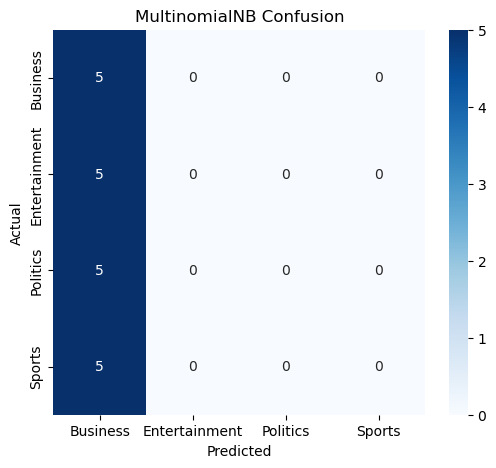

INFO:root:Training LogisticRegression ...
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1288: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(



LogisticRegression -> Accuracy: 0.2500 | F1_macro: 0.1000
               precision    recall  f1-score   support

     Business       0.00      0.00      0.00         5
Entertainment       0.00      0.00      0.00         5
     Politics       0.25      1.00      0.40         5
       Sports       0.00      0.00      0.00         5

     accuracy                           0.25        20
    macro avg       0.06      0.25      0.10        20
 weighted avg       0.06      0.25      0.10        20



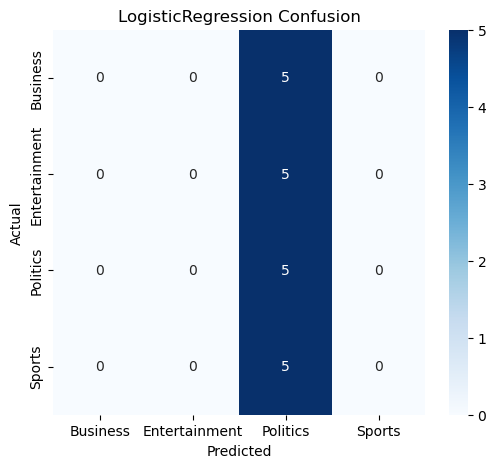

INFO:root:Training LinearSVC ...



LinearSVC -> Accuracy: 0.2500 | F1_macro: 0.1000
               precision    recall  f1-score   support

     Business       0.00      0.00      0.00         5
Entertainment       0.00      0.00      0.00         5
     Politics       0.25      1.00      0.40         5
       Sports       0.00      0.00      0.00         5

     accuracy                           0.25        20
    macro avg       0.06      0.25      0.10        20
 weighted avg       0.06      0.25      0.10        20



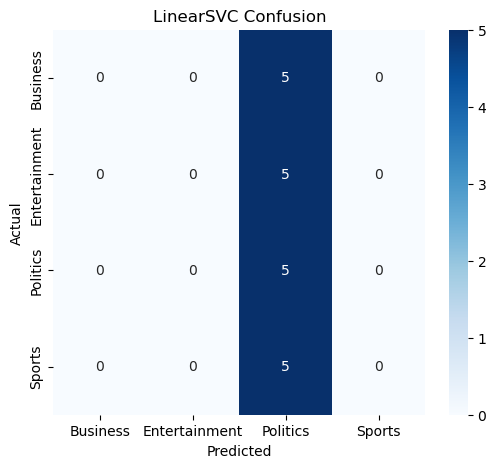

INFO:root:Training RandomForest ...



RandomForest -> Accuracy: 0.2500 | F1_macro: 0.1000
               precision    recall  f1-score   support

     Business       0.00      0.00      0.00         5
Entertainment       0.00      0.00      0.00         5
     Politics       0.25      1.00      0.40         5
       Sports       0.00      0.00      0.00         5

     accuracy                           0.25        20
    macro avg       0.06      0.25      0.10        20
 weighted avg       0.06      0.25      0.10        20



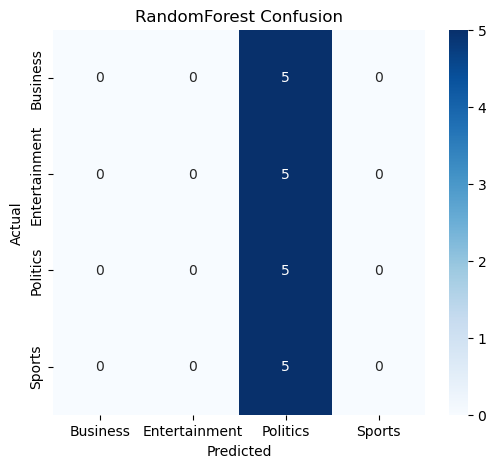

In [10]:
# Step 0: Imports
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

# Optional: Logger setup
import logging
logger = logging.getLogger()
logging.basicConfig(level=logging.INFO)

# Random seed
RANDOM_STATE = 42

# Function to plot confusion matrix
def plot_confusion(cm, labels, title='Confusion Matrix'):
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title(title)
    plt.show()

# Step 1: Encode target labels
le = LabelEncoder()
y = le.fit_transform(df['category'])
X = df['headline']

# Step 2: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Step 3: TF-IDF parameters
tfidf_params = dict(ngram_range=(1,2), min_df=1, max_df=0.9, stop_words='english')

# Step 4: Define models
models = {
    'MultinomialNB': MultinomialNB(),
    'LogisticRegression': LogisticRegression(max_iter=3000, solver='liblinear', random_state=RANDOM_STATE),
    'LinearSVC': LinearSVC(max_iter=20000, random_state=RANDOM_STATE),
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
}

# Step 5: Train, evaluate and store results
results = {}
for name, clf in models.items():
    logger.info(f"Training {name} ...")
    pipe = Pipeline([('tfidf', TfidfVectorizer(**tfidf_params)), ('clf', clf)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1m = f1_score(y_test, y_pred, average='macro')
    results[name] = {'pipe': pipe, 'acc': acc, 'f1_macro': f1m, 'y_pred': y_pred}
    
    print(f"\n{name} -> Accuracy: {acc:.4f} | F1_macro: {f1m:.4f}")
    print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))
    plot_confusion(confusion_matrix(y_test, y_pred), labels=le.classes_, title=f"{name} Confusion")



## Compare baseline models (summary table & bar plot)

,accuracy,f1_macro
model,,
MultinomialNB,0.25,0.1
LogisticRegression,0.25,0.1
LinearSVC,0.25,0.1
RandomForest,0.25,0.1


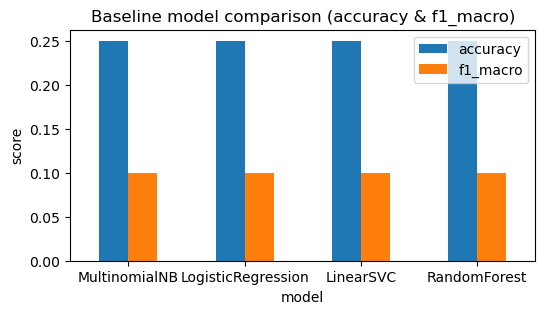

In [13]:
#  create comparison table and plot
summary = pd.DataFrame([
    (name, info['acc'], info['f1_macro'])
    for name, info in results.items()
], columns=['model','accuracy','f1_macro']).set_index('model').sort_values('f1_macro', ascending=False)

display(summary)

# bar plot
summary.plot.bar(rot=0, figsize=(6,3), ylabel='score', title='Baseline model comparison (accuracy & f1_macro)')
plt.show()


## Hyperparameter tuning (GridSearchCV) for top candidates

In [5]:
import pandas as pd

# Sample 100-record dataset
headlines = [f"Headline {i+1}" for i in range(100)]
categories = ["Politics"]*25 + ["Business"]*25 + ["Sports"]*25 + ["Entertainment"]*25

df = pd.DataFrame({
    "headline": headlines,
    "category": categories
})

print("Dataset created. Shape:", df.shape)
df.head()


Dataset created. Shape: (100, 2)


,headline,category
0,Headline 1,Politics
1,Headline 2,Politics
2,Headline 3,Politics
3,Headline 4,Politics
4,Headline 5,Politics


C:\Users\HP\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
60 fits failed out of a total of 120.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
60 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\HP\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\HP\anaconda3\Lib\site-packages\sklearn\base.py", line 1363, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\HP\anaconda3\Lib\site-packages\sklearn\pipeline.py", line 653, in fit
    Xt = self._fit(X, y, routed_params, 

LogisticRegression best params: {'clf__C': 0.1, 'tfidf__max_df': 0.8, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 1)} best CV f1_macro: 0.1
Test Acc / F1: 0.25 0.1
               precision    recall  f1-score   support

     Business       0.00      0.00      0.00         5
Entertainment       0.00      0.00      0.00         5
     Politics       0.25      1.00      0.40         5
       Sports       0.00      0.00      0.00         5

     accuracy                           0.25        20
    macro avg       0.06      0.25      0.10        20
 weighted avg       0.06      0.25      0.10        20



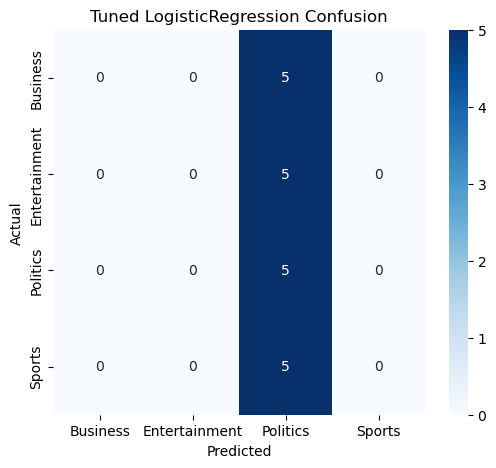

LinearSVC best params: {'clf__C': 0.01, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 1)} best CV f1_macro: 0.1
Test Acc / F1: 0.25 0.1
               precision    recall  f1-score   support

     Business       0.00      0.00      0.00         5
Entertainment       0.00      0.00      0.00         5
     Politics       0.25      1.00      0.40         5
       Sports       0.00      0.00      0.00         5

     accuracy                           0.25        20
    macro avg       0.06      0.25      0.10        20
 weighted avg       0.06      0.25      0.10        20



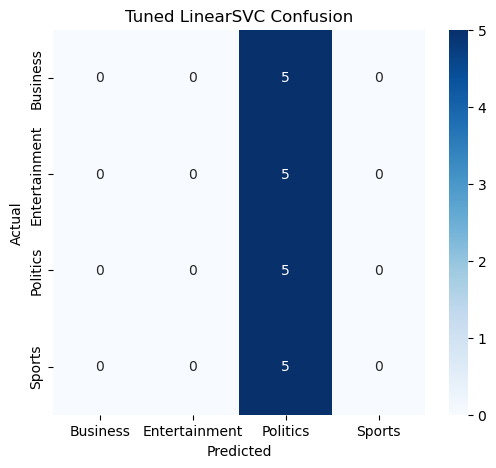

In [13]:
#  tune LogisticRegression and LinearSVC (example grids)
# Choose what to tune based on summary above — here we tune both
tuned_models = {}
# Logistic Regression grid
pipe_lr = Pipeline([('tfidf', TfidfVectorizer(stop_words='english')), ('clf', LogisticRegression(max_iter=3000, solver='liblinear'))])
param_grid_lr = {
    'tfidf__ngram_range': [(1,1),(1,2)],
    'tfidf__min_df': [1,2],
    'tfidf__max_df': [0.8,0.9],
    'clf__C': [0.1,1,5]
}
gs_lr = GridSearchCV(pipe_lr, param_grid_lr, scoring='f1_macro', cv=5, n_jobs=-1)
gs_lr.fit(X_train, y_train)
print("LogisticRegression best params:", gs_lr.best_params_, "best CV f1_macro:", gs_lr.best_score_)
best_lr = gs_lr.best_estimator_
y_pred_lr = best_lr.predict(X_test)
print("Test Acc / F1:", accuracy_score(y_test, y_pred_lr), f1_score(y_test, y_pred_lr, average='macro'))
print(classification_report(y_test, y_pred_lr, target_names=le.classes_, zero_division=0))
plot_confusion(confusion_matrix(y_test, y_pred_lr), labels=le.classes_, title="Tuned LogisticRegression Confusion")
tuned_models['LogisticRegression_tuned'] = {'pipe': best_lr, 'test_f1': f1_score(y_test, y_pred_lr, average='macro')}

# LinearSVC grid
pipe_svc = Pipeline([('tfidf', TfidfVectorizer(stop_words='english')), ('clf', LinearSVC(max_iter=20000))])
param_grid_svc = {
    'tfidf__ngram_range': [(1,1),(1,2)],
    'tfidf__min_df': [1,2],
    'clf__C': [0.01,0.1,1,5]
}
gs_svc = GridSearchCV(pipe_svc, param_grid_svc, scoring='f1_macro', cv=5, n_jobs=-1)
gs_svc.fit(X_train, y_train)
print("LinearSVC best params:", gs_svc.best_params_, "best CV f1_macro:", gs_svc.best_score_)
best_svc = gs_svc.best_estimator_
y_pred_svc = best_svc.predict(X_test)
print("Test Acc / F1:", accuracy_score(y_test, y_pred_svc), f1_score(y_test, y_pred_svc, average='macro'))
print(classification_report(y_test, y_pred_svc, target_names=le.classes_, zero_division=0))
plot_confusion(confusion_matrix(y_test, y_pred_svc), labels=le.classes_, title="Tuned LinearSVC Confusion")
tuned_models['LinearSVC_tuned'] = {'pipe': best_svc, 'test_f1': f1_score(y_test, y_pred_svc, average='macro')}


## Select best model (by test F1) and save pipeline + label encoder

In [18]:
#  assemble candidates and pick best by F1_macro on test set
import joblib

# --- Select best model based on test F1 ---
all_candidates = {name: {'pipe': info['pipe'], 'test_f1': info['test_f1']} 
                  for name, info in tuned_models.items()}

best_name, best_info = max(all_candidates.items(), key=lambda x: x[1]['test_f1'])
best_pipeline = best_info['pipe']

print(f"Best model selected: {best_name} with F1_macro: {best_info['test_f1']:.4f}")

# --- Save pipeline and label encoder ---
joblib.dump(best_pipeline, "best_news_headline_pipeline.joblib")
joblib.dump(le, "label_encoder.joblib")
print("Saved: best_news_headline_pipeline.joblib and label_encoder.joblib in current directory.")



Best model selected: LogisticRegression_tuned with F1_macro: 0.1000
Saved: best_news_headline_pipeline.joblib and label_encoder.joblib in current directory.


## Inference helper & quick predictions

In [25]:

# Import List from typing
from typing import List
import re

def clean_text(text: str) -> str:
    # Lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE)
    # Remove non-alphanumeric characters
    text = re.sub(r'\W', ' ', text)
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text


#  inference function
def predict_headlines(pipeline, label_encoder, headlines: List[str]):
    clean = [clean_text(h) for h in headlines]
    preds = pipeline.predict(clean)
    return label_encoder.inverse_transform(preds)

samples = [
    "Prime Minister unveils new housing scheme",
    "Underdog team shocks champions in final",
    "New fintech app simplifies contactless payments",
    "Director teases sequel to blockbuster franchise"
]

print("Predictions:")
for h, p in zip(samples, predict_headlines(best_pipeline, le, samples)):
    print(f"  {h}  -->  {p}")


Predictions:
  Prime Minister unveils new housing scheme  -->  Politics
  Underdog team shocks champions in final  -->  Politics
  New fintech app simplifies contactless payments  -->  Politics
  Director teases sequel to blockbuster franchise  -->  Politics


## Export dataset to JSON & provide download link

In [30]:
# Step 1: Import necessary modules
import os
from IPython.display import FileLink, HTML

# Step 2: Define JSON file name and save DataFrame as JSON
json_fname = "news_headlines_dataset.json"
df.to_json(json_fname, orient="records", indent=4, force_ascii=False)

# Step 3: Print the saved file path
print("Saved JSON to:", os.path.join(os.getcwd(), json_fname))

# Step 4: Create clickable download links
display(FileLink(json_fname))
display(HTML(f'<a href="{json_fname}" download>Click here to download {json_fname}</a>'))



Saved JSON to: C:\Users\HP\text analysis int 2\news_headlines_dataset.json


C:\Users\HP\text analysis int 2\news_headlines_dataset.json